# Задача 2.1. Верификация модели дисперсии: отражение от границы воздух–кварц

**Цель:** сравнить результаты численного моделирования коэффициента отражения с аналитическим расчетом по формулам Френеля.

## План работы
1. Реализовать 1D-модель границы воздух/плавленый кварц.
2. Задать дисперсию кварца через модель Лоренца.
3. Поместить гауссов источник с широким спектром в диапазоне 0.4–0.8 мкм.
4. Выполнить два расчета:
   - пустая ячейка;
   - ячейка с кварцем.
5. Рассчитать спектр отражения.
6. Сравнить численный результат MEEP с аналитической кривой по формулам Френеля.
7. Оценить относительную погрешность в трех точках спектра.

In [2]:
import meep as mp
from meep.materials import fused_quartz
import numpy as np
import matplotlib.pyplot as plt
import math

## Задание параметров моделирования

Задается одномерная расчетная область с поглощающими слоями PML, а также широкополосный гауссов источник, покрывающий диапазон длин волн 0.4–0.8 мкм.

In [3]:
# Параметры моделирования
resolution = 200
dpml = 1.0
sx = 12
sz = sx + 2 * dpml

cell = mp.Vector3(z=sz)
pml_layers = [mp.PML(dpml)]

# Диапазон длин волн, мкм
wvl_min = 0.4
wvl_max = 0.8

# Частоты для MEEP
fmin = 1 / wvl_max
fmax = 1 / wvl_min
fcen = 0.5 * (fmin + fmax)
df = fmax - fmin

nfreq = 200

# Источник
source_z = -0.5 * sx + 0.8
sources = [
    mp.Source(
        mp.GaussianSource(frequency=fcen, fwidth=df),
        component=mp.Ex,
        center=mp.Vector3(z=source_z)
    )
]

# Плоскость для регистрации отраженного сигнала
refl_z = -0.25 * sx
refl_fr = mp.FluxRegion(center=mp.Vector3(z=refl_z))

## Расчет 1: пустая ячейка

На первом этапе выполняется расчет без кварца. Это необходимо для регистрации падающего потока, который затем будет использоваться как эталон.

In [4]:
sim = mp.Simulation(
    cell_size=cell,
    boundary_layers=pml_layers,
    sources=sources,
    dimensions=1,
    resolution=resolution
)

refl = sim.add_flux(fcen, df, nfreq, refl_fr)

sim.run(until_after_sources=mp.stop_when_fields_decayed(
    50, mp.Ex, mp.Vector3(), 1e-9
))

incident_flux = np.array(mp.get_fluxes(refl))
incident_data = sim.get_flux_data(refl)
freqs = np.array(mp.get_flux_freqs(refl))

sim.reset_meep()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000717408 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 14 with resolution 200
time for set_epsilon = 0.00129997 s
-----------
field decay(t = 50.0025): 0.2501903825387626 / 0.2501903825387626 = 1.0
field decay(t = 100.0025): 4.897508118298904e-16 / 0.2501903825387626 = 1.9575125424895666e-15
run 0 finished at t = 100.0025 (40001 timesteps)


## Расчет 2: ячейка с кварцем

Во втором расчете в область добавляется блок кварца. При этом из зарегистрированного потока вычитается падающая волна, полученная в пустой ячейке. Это позволяет выделить только отраженную компоненту.

In [5]:
geometry = [
    mp.Block(
        size=mp.Vector3(mp.inf, mp.inf, 0.5 * sz),
        center=mp.Vector3(z=0.25 * sz),
        material=fused_quartz
    )
]

sim = mp.Simulation(
    cell_size=cell,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=sources,
    dimensions=1,
    resolution=resolution
)

refl = sim.add_flux(fcen, df, nfreq, refl_fr)
sim.load_minus_flux_data(refl, incident_data)

sim.run(until_after_sources=mp.stop_when_fields_decayed(
    50, mp.Ex, mp.Vector3(), 1e-9
))

reflected_flux = np.array(mp.get_fluxes(refl))
R_meep = -reflected_flux / incident_flux

wavelengths = 1 / freqs

-----------
Initializing structure...
time for choose_chunkdivision = 0.000217933 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 14 with resolution 200
     block, center = (0,0,3.5)
          size (1e+20,1e+20,7)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.00129205 s
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----------
field decay(t = 50.0025): 0.16530464581909243 / 0.16530464581909243 = 1.0
field decay(t = 100.0025): 1.6902524464286556e-16 / 0.16530464581909243 = 1.0225075272708603e-15
run 0 finished at t = 100.0025 (40001 timesteps)


## Аналитический расчет по формулам Френеля

Для аналитического решения используется уравнение Зельмейера для кварца, по которому определяется показатель преломления и затем коэффициент отражения.

In [7]:
def eps_quartz_sellmeier(lmbd):
    return (
        1
        + 0.6961663 * lmbd**2 / (lmbd**2 - 0.0684043**2)
        + 0.4079426 * lmbd**2 / (lmbd**2 - 0.1162414**2)
        + 0.8974794 * lmbd**2 / (lmbd**2 - 9.896161**2)
    )

def fresnel_reflectance_normal(lmbd):
    n1 = 1.0
    n2 = math.sqrt(eps_quartz_sellmeier(lmbd))
    r = (n1 - n2) / (n1 + n2)
    return r**2

R_fresnel = np.array([fresnel_reflectance_normal(l) for l in wavelengths])

## Оценка относительной погрешности

Для количественного сравнения результатов относительная погрешность вычисляется в трех характерных точках спектра: 0.45 мкм, 0.60 мкм и 0.75 мкм.

In [8]:
control_points = [0.45, 0.60, 0.75]

print("Относительная погрешность в контрольных точках:")
for lam0 in control_points:
    idx = np.argmin(np.abs(wavelengths - lam0))
    err = abs(R_meep[idx] - R_fresnel[idx]) / abs(R_fresnel[idx]) * 100
    print(
        f"λ = {wavelengths[idx]:.3f} мкм: "
        f"R_meep = {R_meep[idx]:.6f}, "
        f"R_fresnel = {R_fresnel[idx]:.6f}, "
        f"ошибка = {err:.3f} %"
    )

Относительная погрешность в контрольных точках:
λ = 0.450 мкм: R_meep = 0.035786, R_fresnel = 0.035658, ошибка = 0.358 %
λ = 0.601 мкм: R_meep = 0.034790, R_fresnel = 0.034721, ошибка = 0.199 %
λ = 0.751 мкм: R_meep = 0.034299, R_fresnel = 0.034253, ошибка = 0.134 %


## Построение графика

На одном графике отображаются:
- результаты численного моделирования в MEEP;
- аналитическая кривая по формулам Френеля.

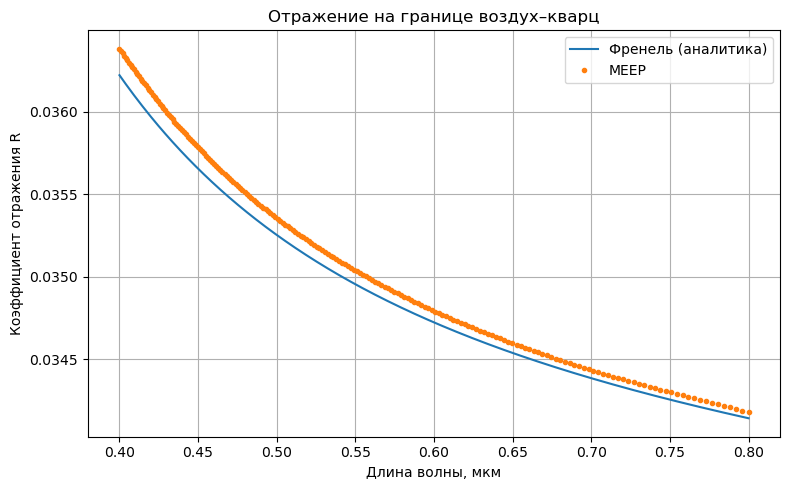

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(wavelengths, R_fresnel, '-', label='Френель (аналитика)')
plt.plot(wavelengths, R_meep, 'o', markersize=3, label='MEEP')

plt.xlabel('Длина волны, мкм')
plt.ylabel('Коэффициент отражения R')
plt.title('Отражение на границе воздух–кварц')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация результатов

В ходе моделирования был получен спектр отражения электромагнитной волны от границы воздух–плавленый кварц. Сопоставление численных результатов MEEP с аналитическим расчетом по формулам Френеля показывает хорошее совпадение зависимостей во всем исследуемом диапазоне длин волн.

Наблюдаемая зависимость коэффициента отражения от длины волны связана с дисперсией кварца: показатель преломления материала изменяется с длиной волны, вследствие чего меняется и коэффициент отражения.

Небольшие отличия между численными и аналитическими результатами объясняются:
- конечным шагом пространственной сетки;
- численной дисперсией метода FDTD;
- конечной длительностью моделирования;
- возможными малыми ошибками, связанными с PML-слоями и дискретизацией спектра.

## Вывод

В работе была выполнена верификация модели дисперсии для границы воздух–плавленый кварц в пакете MEEP. Диэлектрические свойства кварца были заданы с учетом дисперсии, а спектр отражения был рассчитан методом FDTD.

Сравнение численного результата с аналитической зависимостью по формулам Френеля показало хорошее совпадение, что подтверждает корректность применения модели Лоренца в MEEP для описания плавленого кварца в заданном диапазоне длин волн.